In this notebook, we compare at large overparametrization (i.e in the kernel limit) the true variance $\Delta$ and the ensemble variance with the Bayes-optimal variance. 
Then, we look at what's the optimal way to parametrize the scaling of the variance to match the true variance by using a validation set.

**NOTE** : We can also get from our overparametrized paper the variance `v` for the Pseudo-Baye, and we can do a bias variance decomposition

In [1]:
using BootstrapAsymptotics
using Plots
using ProgressBars

In [2]:
# for the erf activation
κ1    =  2.0 / sqrt(3* pi)
κstar = 0.200364

0.200364

In [ ]:
function get_variances(sample_over_teacher::Real, Δ::Real, κ1::Real, κstar::Real, λ::Real; algos)::Dict
    dict_return = Dict()

    # take large value (but not too large for numerical precision)
    student_over_teacher_dim = 100.0

    for algo in algos
        problem = BootstrapAsymptotics.build_ridge_overparametrized(
            α                        = sample_over_teacher / student_over_teacher_dim,
            true_Δ                   = Δ,
            λ                        = λ, 
            true_ρ                    = 1.0,
            κ1                       = κ1,
            κstar                    = κstar,
            student_over_teacher_dim = student_over_teacher_dim
        )

        result = BootstrapAsymptotics.state_evolution(
            problem,
            algo,
            algo;
            rtol=1e-4,
            max_iteration=100,
            show_progress=false,
        )
        dict_return[algo] = result
        end

    return dict_return
end

get_variances (generic function with 2 methods)

In [ ]:
# sample_over_teacher_range = 0.5:0.5:5.0
sample_over_teacher_range = 10 .^ range(0.0, stop=4, length=100)

algos = [
    NoResampling(),
    Subsampling(r = 0.8),
    PairBootstrap(p_max = 5)
]

Δ = 1.0
λ = 1e-4

variances = Dict([
    algo => [] for algo in algos
])

for sample_over_teacher in ProgressBar(sample_over_teacher_range)
    result = get_variances(
        sample_over_teacher,
        Δ,
        κ1,
        κstar,
        λ;
        algos = algos
    )

    for algo in algos
        push!(variances[algo], result[algo].overlaps.Q[1, 1] - result[algo].overlaps.Q[1, 2])
    end

end

0.0%┣                                              ┫ 0/100 [00:00<00:00, -0s/it]
100.0%┣████████████████████████████████████████┫ 100/100 [00:00<00:00, 9.4kit/s]
100.0%┣████████████████████████████████████████┫ 100/100 [00:00<00:00, 9.2kit/s]


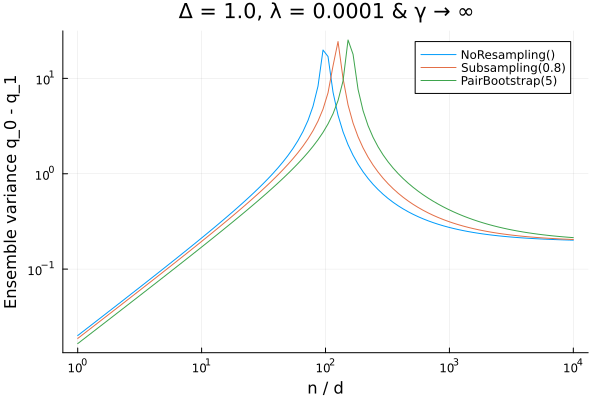

In [36]:
plot(xlabel="n / d", ylabel="Ensemble variance q_0 - q_1", xscale=:log10, yscale=:log10)

for algo in algos
    plot!(sample_over_teacher_range, variances[algo], label="$algo")
end

display(plot!(legend=true, title="Δ = $Δ, λ = $λ & γ → ∞"))

---

Below we run at fixed n / d but change the intrinsic noise 

In [ ]:
Δ_range = 10 .^ range(-2.0, stop=4.0, length=100)
λ = 1e-4
sample_over_teacher = 2.0

variances = Dict([
    algo => [] for algo in algos
])

for Δ in Δ_range
    result = get_variances(
        sample_over_teacher,
        Δ,
        κ1,
        κstar,
        λ;
        algos = algos
    )

    for algo in algos
        push!(variances[algo], result[algo].overlaps.Q[1, 1] - result[algo].overlaps.Q[1, 2])
    end
end

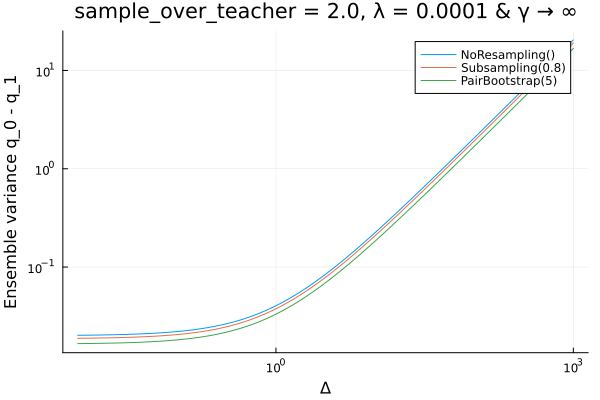

In [50]:
plot(xlabel="Δ", ylabel="Ensemble variance q_0 - q_1", xscale=:log10, yscale=:log10)

for algo in algos
    plot!(Δ_range, variances[algo], label="$algo")
end

display(plot!(legend=true, title="sample_over_teacher = $sample_over_teacher, λ = $λ & γ → ∞"))